### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [1]:
import os

import mlflow
import mlflow.xgboost

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

In [2]:
not_use_cols = ['date']
attr_cols = ['open', 'high', 'low', 'close', 'volume', 'average', 'barCount']
hist_5_cols = ['h5s_high_max',  'h5s_low_min',  'h5s_barCount_sum',  'h5s_volume_sum', 'h5s_average_avg']
hist_10_cols= ['h10s_high_max', 'h10s_low_min', 'h10s_barCount_sum', 'h10s_volume_sum','h10s_average_avg']
hist_15_cols= ['h15s_high_max', 'h15s_low_min', 'h15s_barCount_sum', 'h15s_volume_sum','h15s_average_avg']
pred_cols= [ 'f5s_average','f5s_arrow', 'f5s_10c_arrow', 'f5s_20c_arrow']
x_cols = [ ]

x_cols += attr_cols + hist_5_cols + hist_10_cols + hist_15_cols
y_cols = ['f5s_average']  # ,  'p5s_bucket', 'p30s_bucket', 'p60s_bucket']
bin_counts = 3

test_file = "./TSLA-Stocks/All.csv"

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        # 'objective': 'multi:softprob',
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # 'num_class': bin_counts,
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }
#
#  Call Main
#

In [3]:
mlflow.set_experiment("xgb-binary-" + y_cols[0])
mlflow.xgboost.autolog()

In [4]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

In [5]:
def load_data(file_list, x_cols_names, y_cols_names, data_type="data"):
    # Load Training Data
    from os.path import exists

    data = None
    ctr = 1
    for file in file_list:

        file_name = os.getcwd() + "/../ml_cp18/data/" + file

        data_tmp = pd.read_csv(file_name, low_memory=False)
        mlflow.log_param( data_type + f" file {ctr}", file)
        ctr += 1
        if data is None:
            data = data_tmp
        else:
            data = data.append(data_tmp, ignore_index=True)

    msg = f"raw:  {data.shape}"

    all_cols = x_cols_names + y_cols_names
    data = data [ all_cols ]
    data = data.dropna()
    msg += f" na {data.shape}"

    X_features = data[x_cols]
    y_features = data[y_cols].astype('int')
    print (data_type + " size", msg)
    mlflow.log_param(data_type + " size", msg)
    return X_features, y_features, data

In [8]:
# XGB Parameters

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        # 'objective': 'multi:softprob',
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # 'num_class': bin_counts,
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }

In [9]:
mlflow.set_experiment("xgb-binary-" + y_cols[0])
mlflow.xgboost.autolog()

# Code

In [10]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='g'):
    plt.figure(figsize=[7, 6])
    norm_cm = cm
    if normalized:
        norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(norm_cm, annot=cm, fmt=fmt, xticklabels=classes, yticklabels=classes, cmap=cmap)

## load data

In [11]:
x_train, y_train, train = load_data(model_file_list, x_cols, y_cols, data_type="Training")
# Load Test Data
x_test, y_test, test = load_data([test_file], x_cols, y_cols, data_type="Testing")


Training size raw:  (137579, 267) na (121794, 23)
Testing size raw:  (8347, 267) na (7745, 23)


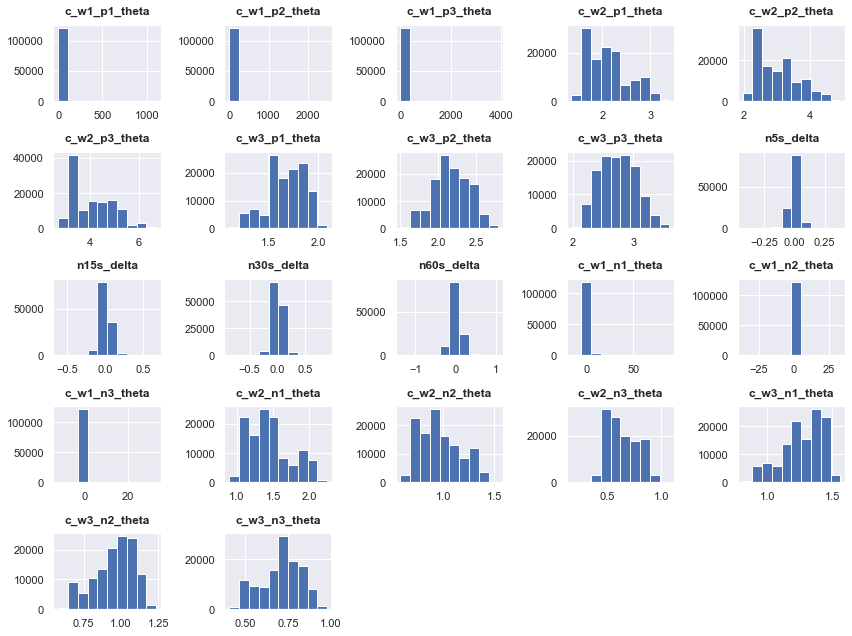

In [12]:
# fig, ax = plt.subplots()
sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()


## Scale Data

In [13]:
# Standard Scaled X Prediction
scalar = StandardScaler()
scalar.fit(x_train)
x_train = pd.DataFrame(scalar.transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(scalar.transform(x_test), columns=x_test.columns)
#x_train = scalar.transform(x_train)
#x_test = scalar.transform(x_test)


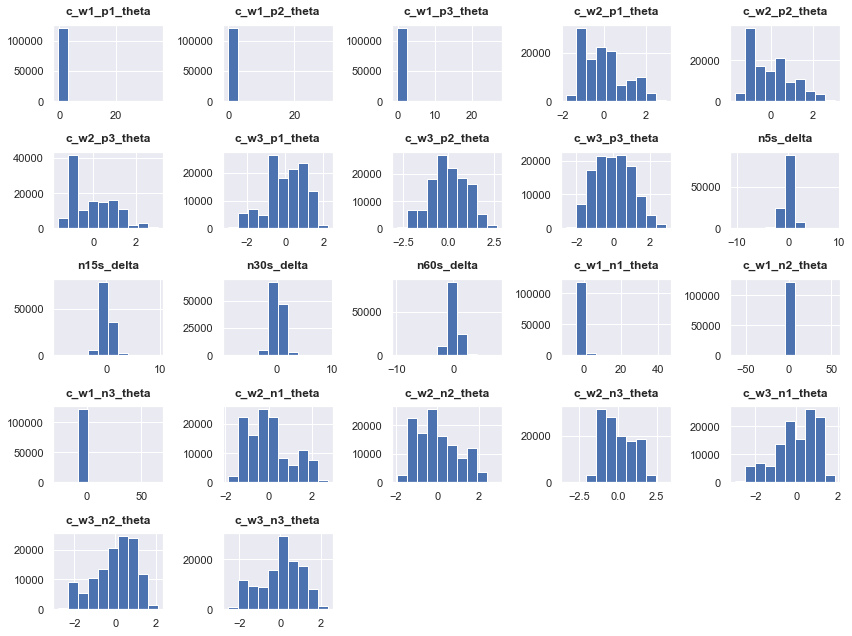

In [17]:
# fig, ax = plt.subplots()
sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()


## mlflow logging

In [14]:
# mlflow.start_run()

In [15]:
params["feature_names"] = x_cols
mlflow.log_param('y_col', ', '.join(y_cols))
mlflow.log_param('X_cols', ', '.join(x_cols))
mlflow.log_param('XGB Params', params)

In [16]:
!pip3 install plotly

## Create XGB Model

In [18]:
xgb = XGBClassifier(**params)

# Train model & predict
xgb.fit(x_train, y_train[y_cols])
y_pred = xgb.predict(x_test)


2022/01/13 18:22:07 WARNING mlflow.utils: Truncated the value of the key `feature_names`. Truncated value: `['c_w1_p1_theta', 'c_w1_p2_theta', 'c_w1_p3_theta', 'c_w2_p1_theta', 'c_w2_p2_theta', 'c_w2_p3_theta', 'c_w3_p1_theta', 'c_w3_p2_theta', 'c_w3_p3_theta', 'n5s_delta', 'n15s_delta', 'n30s_delta', 'n60s_delta', 'c_w1_n1_theta', 'c_w1_n2_theta', 'c_w...`


[18:22:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:576: 
Parameters: { "_kfold", "_tuning_objective_metric", "copy_X", "feature_names", "fit_intercept", "normalize", "num_round" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




In [19]:
precision, recall, f1, y_true = precision_recall_fscore_support(y_test[y_cols], y_pred, average=None)
# from sklearn.metrics import precision_score, recall_score
ps = precision_score(y_test[y_cols], y_pred)
rs = recall_score(y_test[y_cols], y_pred)

#  y_true = y_true.astype('int')

accuracy = accuracy_score(y_test[ y_cols ], y_pred)
print(f"accuracy: {accuracy:.3f}")
mlflow.log_metric('Accuracy', accuracy)

# pd.options.display.float_format = '{:,.3f}'.format

for idx in range(len(recall)):
    mlflow.log_metrics({f'recall-{idx}': recall[idx],
                        f'precision-{idx}': precision[idx],
                        f'f1-{idx}': f1[idx],
                        f'y_true-{idx}': y_true[idx]}, step=idx)
    idx += 1

accuracy: 0.505


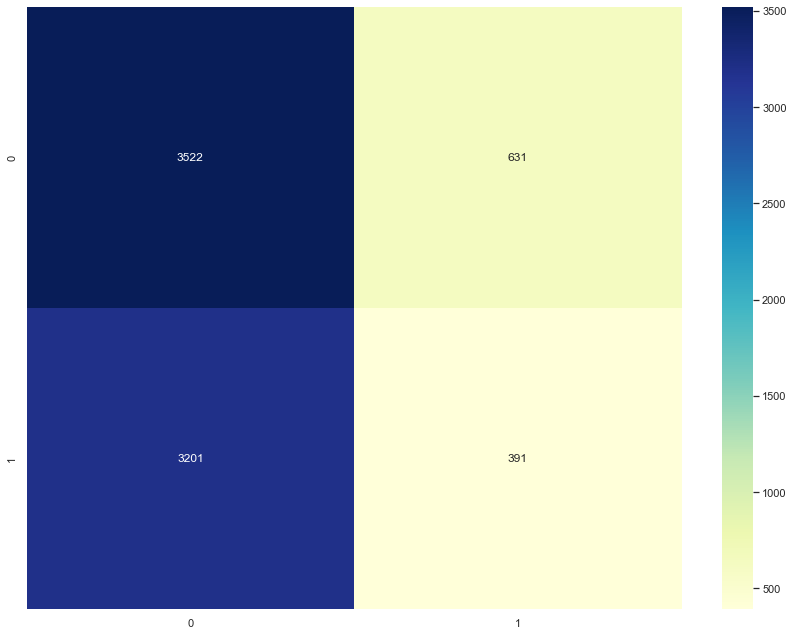

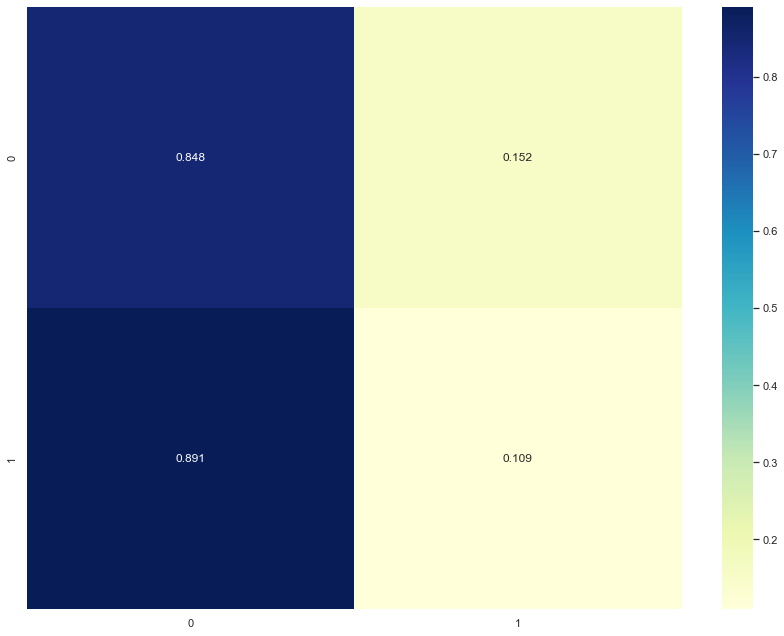

In [33]:
# from mlflow.models.signature import infer_signature
# signature = infer_signature(x_train, xgb.predict(xgb.DMatrix(data=x_train, label=y_train)))
# mlflow.xgboost.log_model(xgb, "model") #, signature=signature)""

cm = confusion_matrix(y_test[ y_cols ], y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots()
sns.set(rc = {'figure.figsize':(12,9)})
sns.heatmap(cm, annot=True, cmap="YlGnBu",fmt='d')
fig.savefig("ConfusionMatrix.png")
mlflow.log_figure(fig, "ConfusionMatrix.png")
plt.show()

sns.heatmap(cm_pct, annot=True, cmap="YlGnBu", fmt=".3f")
fig.savefig("ConfusionMatrixPct.png")
mlflow.log_figure(fig, "ConfusionMatrixPct.png")
plt.show()


# feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
# feature_importances.sort_values('importance', ascending=False)


In [21]:
feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
feature_importances.sort_values('importance', ascending=False)

,importance
c_w1_p3_theta,0.082819
c_w2_p3_theta,0.069948
c_w3_p3_theta,0.067388
c_w1_p2_theta,0.063788
c_w3_p2_theta,0.055655
c_w3_n1_theta,0.050774
c_w3_p1_theta,0.049412
c_w1_n1_theta,0.048746
c_w2_n1_theta,0.046990
c_w2_p2_theta,0.045861


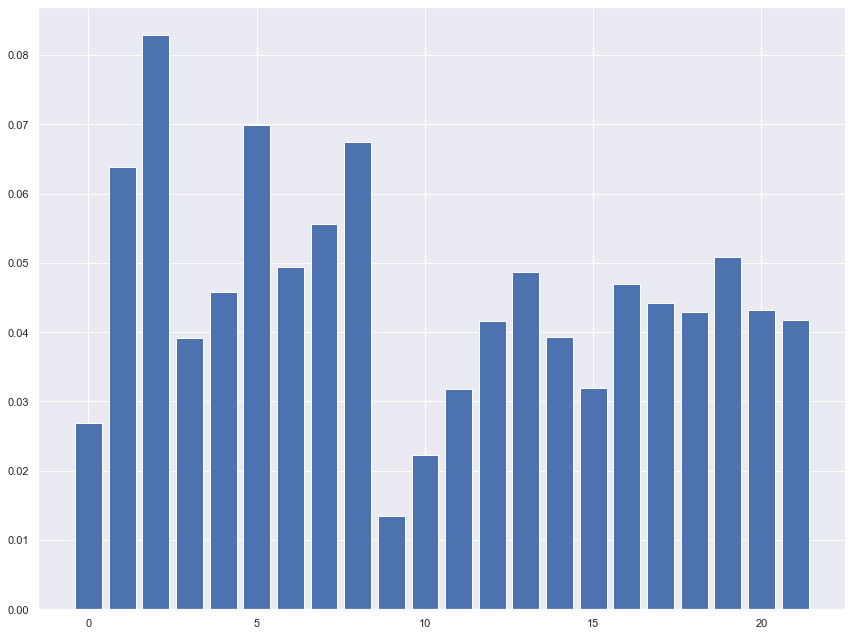

In [22]:
# plot
from matplotlib import pyplot
pyplot.bar(range(len(xgb.feature_importances_)), xgb.feature_importances_)
pyplot.show()

In [23]:
mlflow.end_run()